# User Overview EDA

**Goals:**
1. Clean data — missing values & outliers (replaced with column mean)
2. Univariate analysis (numeric + graphical)
3. Bivariate analysis — each app vs total data
4. Decile segmentation by total duration
5. Correlation matrix + PCA

> Reuses `user_agg` from Task 2.1 via `aggregate_user_sessions()`.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from tellco_user_analytics.data.loader import load_xdr_sessions
from tellco_user_analytics.analysis.user_overview import aggregate_user_sessions
from tellco_user_analytics.analysis.preprocessing import (
    treat_missing_and_outliers,
    MeanImputeOutlierTransformer,
)
from tellco_user_analytics.analysis.eda import (
    ANALYSIS_COLUMNS,
    APP_COLUMNS,
    variable_overview,
    basic_metrics,
    dispersion_parameters,
    duration_decile_analysis,
    top_decile_classes,
    app_total_correlation,
    application_correlation_matrix,
    run_pca,
    interpret_pca,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load & aggregate (Task 2.1 output)

In [2]:
sessions = load_xdr_sessions()
user_agg = aggregate_user_sessions(sessions)
print(f"Users: {len(user_agg):,}")
user_agg.head(3)

Users: 106,856


,MSISDN/Number,session_count,total_duration_ms,total_dl_bytes,total_ul_bytes,Social Media,Google,Email,Youtube,Netflix,Gaming,Other,total_data_bytes
0,"33,601,001,722.00",1,"116,720.00","842,637,466.00","36,053,108.00","2,232,135.00","4,389,005.00","1,331,362.00","21,624,548.00","27,180,981.00","812,458,661.00","386,570,872.00","878,690,574.00"
1,"33,601,001,754.00",1,"181,230.00","120,755,184.00","36,104,459.00","2,660,565.00","5,334,863.00","3,307,781.00","12,432,223.00","11,221,763.00","119,750,078.00","281,710,071.00","156,859,643.00"
2,"33,601,002,511.00",1,"134,969.00","556,659,663.00","39,306,820.00","3,195,623.00","3,443,126.00","3,205,380.00","21,333,570.00","19,353,900.00","538,827,713.00","501,693,672.00","595,966,483.00"


## 2. Variable overview (for slides)

Describe each relevant variable, its dtype, and missing counts.

In [8]:
cols = [c for c in ANALYSIS_COLUMNS if c in user_agg.columns]
variable_overview(user_agg, columns=cols)

,variable,dtype,non_null,missing,missing_pct
0,session_count,int64,106856,0,0.00
1,total_duration_ms,float64,106856,0,0.00
2,total_dl_bytes,float64,106856,0,0.00
3,total_ul_bytes,float64,106856,0,0.00
4,total_data_bytes,float64,106856,0,0.00
5,Social Media,float64,106856,0,0.00
6,Google,float64,106856,0,0.00
7,Email,float64,106856,0,0.00
8,Youtube,float64,106856,0,0.00
9,Netflix,float64,106856,0,0.00


## 3. Preprocessing — missing values & outliers

**Method:** IQR rule to flag outliers; replace missing + outliers with **column mean** (per challenge spec).

Sklearn `Pipeline` chains the transformer for reuse in later tasks.

In [9]:
preprocess_pipeline = Pipeline(
    steps=[
        ("clean", MeanImputeOutlierTransformer(columns=cols)),
    ]
)

user_clean = preprocess_pipeline.fit_transform(user_agg)
cleaning_report = preprocess_pipeline.named_steps["clean"].report_

display(cleaning_report.sort_values("outliers_replaced", ascending=False))
print(f"Total outlier replacements: {cleaning_report['outliers_replaced'].sum():,}")

/Users/tesfamariamasfaw/Documents/tes/ML projects/tellco-user-analytics/src/tellco_user_analytics/analysis/preprocessing.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.389776896009583' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cleaned.loc[missing_mask, col] = col_mean


,column,missing_replaced,outliers_replaced,replacement_value
1,total_duration_ms,0,8052,"146,167.16"
3,total_ul_bytes,0,7456,"57,309,422.41"
8,Youtube,0,6459,"31,558,399.28"
9,Netflix,0,6371,"31,538,332.31"
6,Google,0,5883,"10,882,434.42"
7,Email,0,5645,"3,148,795.81"
4,total_data_bytes,0,5282,"690,962,103.31"
2,total_dl_bytes,0,4708,"633,652,680.89"
11,Other,0,4418,"598,508,764.28"
10,Gaming,0,4396,"599,769,010.72"


Total outlier replacements: 66,216


## 4. Basic metrics & dispersion (non-graphical univariate)

**Why it matters:** Mean/median show typical usage; std/IQR/CV reveal spread — heavy tails in telecom data often mean a few power users drive most traffic.

In [10]:
display(basic_metrics(user_clean, columns=cols))
dispersion_parameters(user_clean, columns=cols)

,mean,median,std,min,max
session_count,1.29,1.00,0.54,0.00,3.00
total_duration_ms,"116,775.59","102,740.00","68,222.70","7,142.00","324,991.00"
total_dl_bytes,"570,588,899.64","570,367,723.00","327,256,623.48","8,827,082.00","1,546,146,640.00"
total_ul_bytes,"50,491,886.14","46,793,865.50","20,052,654.43","2,866,892.00","109,736,398.00"
total_data_bytes,"618,406,809.34","617,923,138.00","332,977,741.21","33,249,009.00","1,605,748,767.00"
Social Media,"2,306,856.89","2,303,756.00","1,384,352.64","1,563.00","6,451,407.00"
Google,"9,676,310.06","9,586,153.00","4,900,679.93","40,330.00","24,122,202.00"
Email,"2,803,580.86","2,799,824.50","1,463,576.55","18,176.00","7,105,100.00"
Youtube,"27,913,436.27","26,800,376.00","13,244,519.64","78,903.00","66,864,198.00"
Netflix,"27,924,654.77","26,718,889.50","13,345,094.17","184,569.00","67,103,969.00"


,variable,range,variance,std,iqr,cv
0,session_count,3.00,0.29,0.54,0.39,0.42
1,total_duration_ms,"317,849.00","4,654,337,443.27","68,222.70","84,234.00",0.58
2,total_dl_bytes,"1,537,319,558.00","107,096,897,610,300,832.00","327,256,623.48","451,400,060.00",0.57
3,total_ul_bytes,"106,869,506.00","402,108,949,522,594.56","20,052,654.43","20,913,947.66",0.40
4,total_data_bytes,"1,572,499,758.00","110,874,176,144,472,432.00","332,977,741.21","452,103,705.50",0.54
5,Social Media,"6,449,844.00","1,916,432,221,906.23","1,384,352.64","1,941,795.50",0.60
6,Google,"24,081,872.00","24,016,663,744,668.43","4,900,679.93","6,300,522.75",0.51
7,Email,"7,086,924.00","2,142,056,304,225.65","1,463,576.55","1,937,239.50",0.52
8,Youtube,"66,785,295.00","175,417,300,384,951.25","13,244,519.64","15,918,254.00",0.47
9,Netflix,"66,919,400.00","178,091,538,320,542.34","13,345,094.17","16,016,099.00",0.48


### Interpretation

**Typical user profile**
- Most customers appear **once** in the dataset (`session_count` median = 1, mean ≈ 1.4, max = 3), so behaviour is measured over a very small number of sessions per user.
- Average session time is **~117k ms (~2 min)** with median slightly lower (~103k ms), indicating a modest right skew in duration even after cleaning.

**Traffic is dominated by two application buckets**
- Per-user averages show **Gaming (~542 MB)** and **Other (~540 MB)** account for the vast majority of data volume; combined they explain most of `total_data_bytes` (~618 MB mean).
- Lighter apps — **Social Media / Email (~2–3 MB)**, **Google (~10 MB)**, **Youtube / Netflix (~28 MB)** — are an order of magnitude smaller on average but still material for segmentation.

**Dispersion & spread**
- **Coefficient of variation (CV)** is highest for **Social Media, Gaming, and Other (~0.60)**, meaning relative spread is largest there: users differ more in how much they use those categories.
- **Upload traffic (`total_ul_bytes`, CV ≈ 0.40)** is more uniform than download or total bytes, suggesting download-heavy usage patterns.
- **Mean ≈ median** on most byte columns after IQR cleaning — expected, because outliers were replaced with column means. Dispersion here reflects the bulk of users, not extreme power users (see histograms in Section 5 for shape).

**Business takeaway**
- Network load is **concentrated in Gaming + Other** traffic; product and capacity planning should prioritise those categories.
- High CV on byte volumes implies **meaningful user heterogeneity** remains after cleaning — decile and correlation analysis (Sections 6–7) are needed to identify who drives volume.

## 5. Graphical univariate analysis

Histograms for skewed byte volumes; boxplots highlight outliers (already treated above).

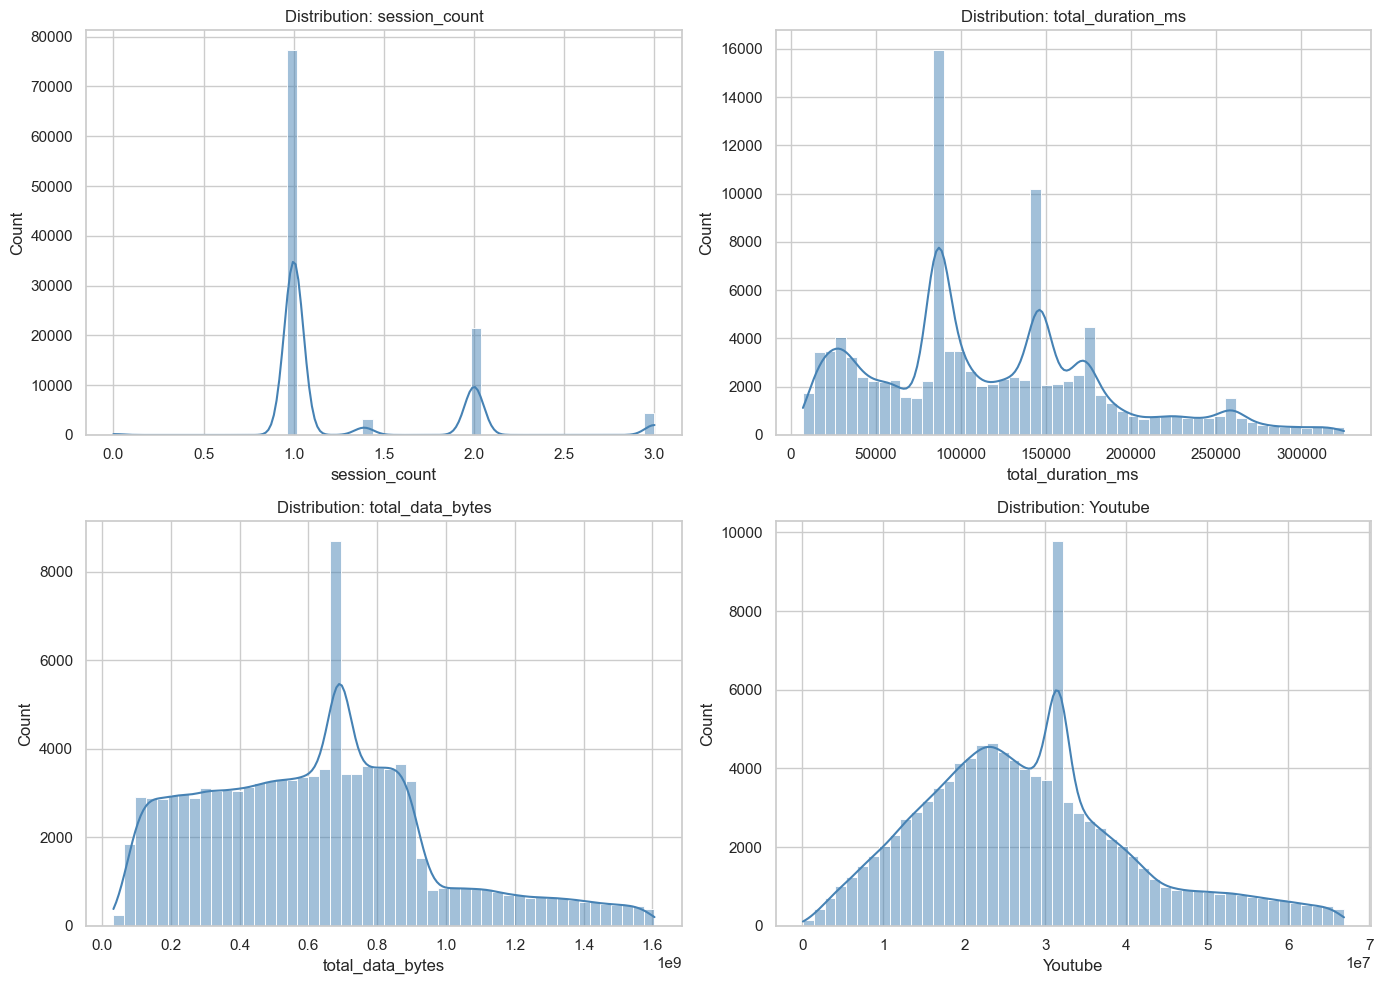

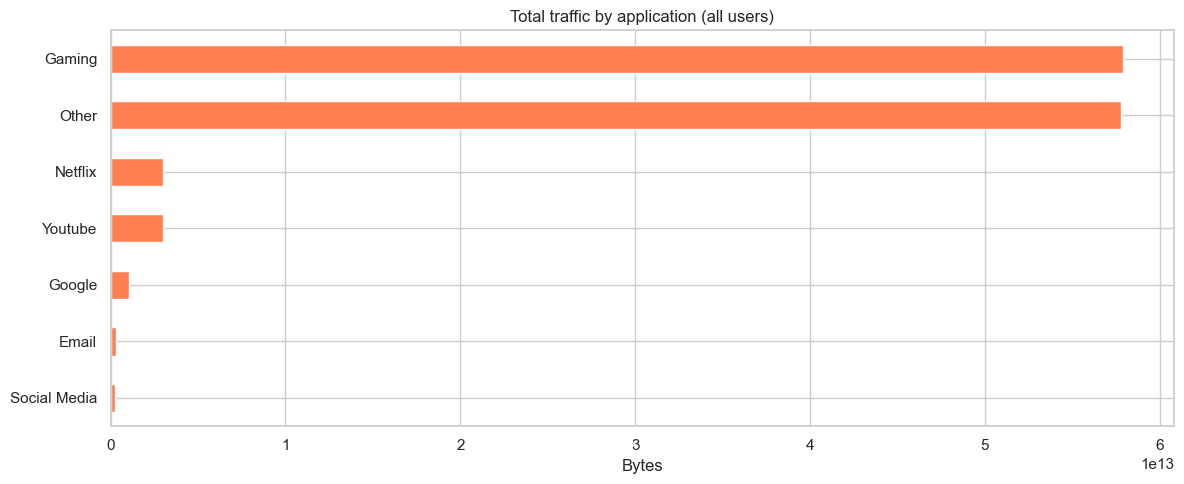

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_vars = ["session_count", "total_duration_ms", "total_data_bytes", "Youtube"]

for ax, var in zip(axes.flat, plot_vars):
    sns.histplot(user_clean[var], bins=50, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution: {var}")
    ax.set_xlabel(var)

plt.tight_layout()
plt.show()

# Application traffic — log scale for readability
fig, ax = plt.subplots(figsize=(12, 5))
app_totals = user_clean[APP_COLUMNS].sum().sort_values(ascending=True)
app_totals.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Total traffic by application (all users)")
ax.set_xlabel("Bytes")
plt.tight_layout()
plt.show()

## 6. Bivariate analysis — each application vs total data

Scatter + Pearson correlation: which apps drive overall data consumption?

,corr_with_total_data
Gaming,0.97
Netflix,0.41
Youtube,0.41
Google,0.39
Email,0.37
Social Media,0.35
Other,0.34


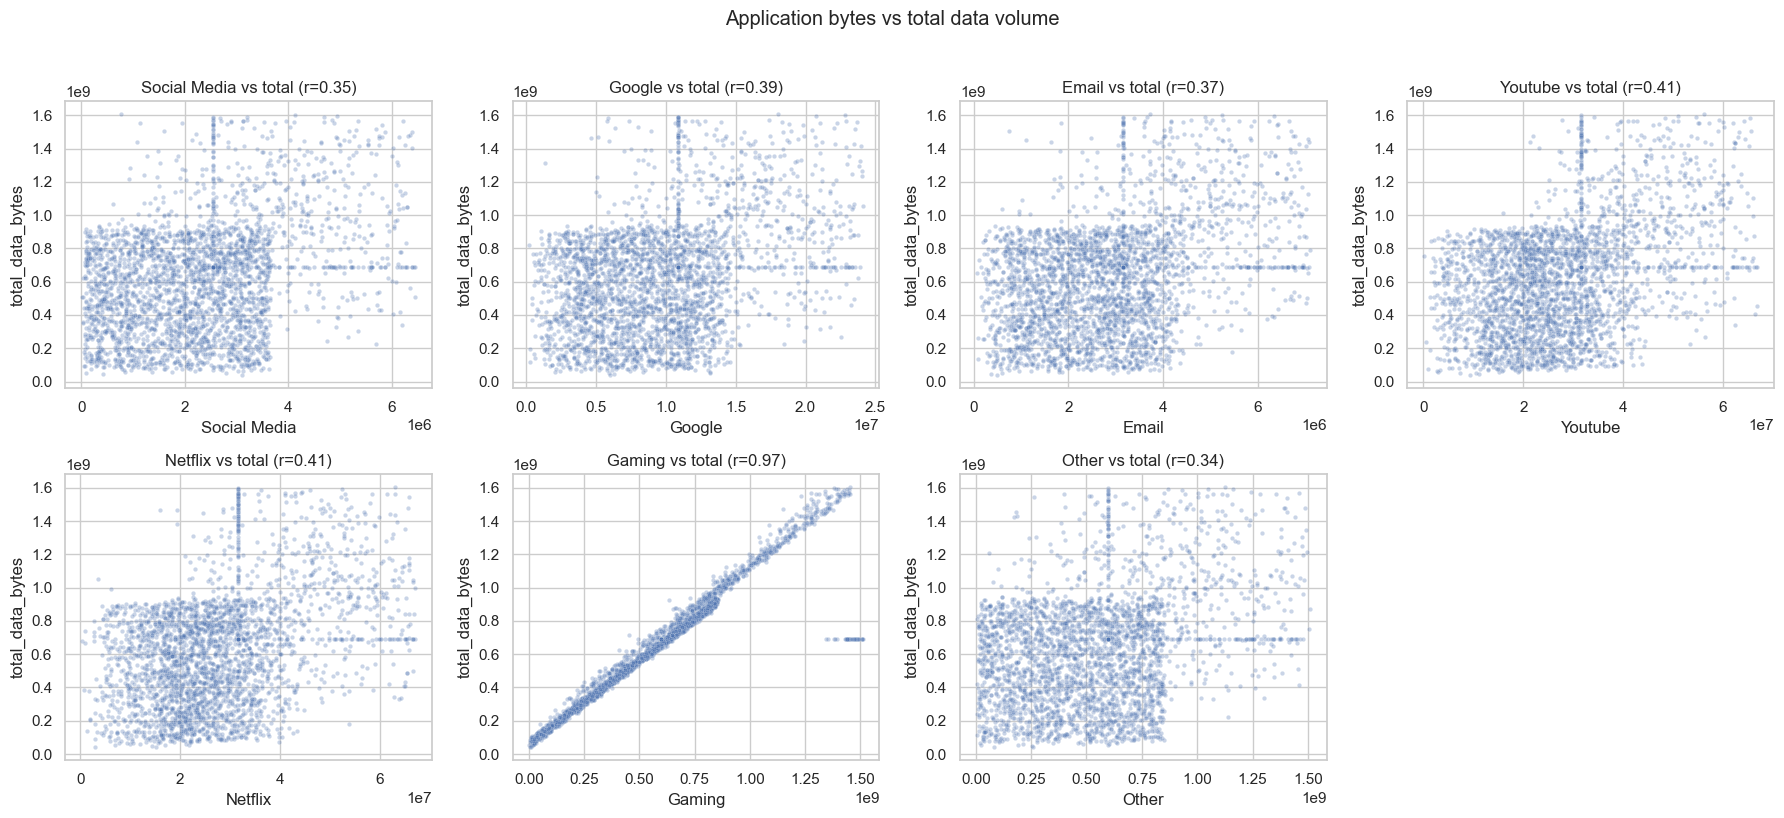

In [19]:
app_corr = app_total_correlation(user_clean)
display(app_corr.to_frame())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, app in zip(axes, APP_COLUMNS):
    sample = user_clean.sample(min(3000, len(user_clean)), random_state=42)
    sns.scatterplot(
        data=sample, x=app, y="total_data_bytes", alpha=0.3, s=10, ax=ax
    )
    r = app_corr[app]
    ax.set_title(f"{app} vs total (r={r:.2f})")

axes[-1].axis("off")
plt.suptitle("Application bytes vs total data volume", y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

**Gaming drives total data volume**
- **Gaming vs total data ($r \approx 0.97$)** shows an almost perfect linear relationship — points fall tightly on the diagonal from the origin. Gaming bytes alone explain most of the variation in `total_data_bytes`; when gaming usage rises, total volume rises almost proportionally.

**Video streaming is a secondary lever**
- **Youtube ($r \approx 0.41$)** and **Netflix ($r \approx 0.41$)** show moderate positive correlation. Streaming contributes meaningfully to total usage, but scatter is much wider than Gaming — users can have high total data without proportionally high streaming, and vice versa.

**Light apps barely move the needle on total volume**
- **Google ($r \approx 0.39$)**, **Email ($r \approx 0.37$)**, **Social Media ($r \approx 0.35$)**, and **Other ($r \approx 0.34$)** all show weak-to-moderate correlation. Most points cluster at the lower-left (low app bytes, low total), reflecting many light users on these categories.

**Visual patterns worth noting**
- **Scale mismatch:** Gaming and Other x-axes reach ~$1.5 \times 10^9$ bytes; Social Media and Email stay below ~$6 \times 10^6$ — orders of magnitude smaller absolute traffic.
- **Horizontal banding** on several plots (e.g. Social Media, Google, Email) around ~$0.7 \times 10^9$ and ~$1.4 \times 10^9$ on the total-data axis likely reflects **IQR outlier replacement** pulling many users to similar column means, not natural usage tiers.
- The dense lower-left cluster in non-Gaming plots confirms a **long tail of low-usage users** for communication and browsing apps.

**Business takeaway**
- Capacity and product strategy should **prioritise Gaming** as the primary driver of per-user data volume.
- Youtube/Netflix are the next targets for streaming-focused offers or network optimisation.
- Social, Email, and Google are poor predictors of total data spend — segment users on Gaming (and duration/deciles) rather than these lighter categories.

## 7. Decile segmentation by total duration

Users ranked by `total_duration_ms` into 10 deciles (D1 = lowest, D10 = highest).  
**Top five decile classes** = D6–D10 (most engaged by time on network).

In [ ]:
decile_summary = duration_decile_analysis(user_clean)
top_five_deciles = top_decile_classes(decile_summary, top_n=5)

display(decile_summary)
print("\nTop 5 decile classes (D6–D10):")
display(top_five_deciles)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=decile_summary, x="decile", y="total_data_bytes", ax=ax, color="seagreen")
ax.set_title("Total data volume by duration decile")
ax.set_ylabel("Total bytes (DL+UL)")
plt.tight_layout()
plt.show()

## 8. Correlation matrix (application traffic)

In [ ]:
corr_matrix = application_correlation_matrix(user_clean)
display(corr_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between application data volumes")
plt.tight_layout()
plt.show()

## 9. PCA — dimensionality reduction on application usage

In [ ]:
pca_result = run_pca(user_clean, n_components=len(APP_COLUMNS))

display(pca_result.explained_variance.to_frame())
display(pca_result.loadings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pca_result.explained_variance.cumsum().plot(kind="bar", ax=axes[0], color="purple")
axes[0].set_title("Cumulative explained variance")
axes[0].set_ylabel("Ratio")

sns.heatmap(pca_result.loadings, annot=True, cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("PCA loadings")
plt.tight_layout()
plt.show()

print("\nPCA interpretation (max 4 bullets):")
for bullet in interpret_pca(pca_result):
    print(f"  • {bullet}")

## 10. Key takeaways (for slides)

**Copy these after running the notebook and adjust with your actual numbers:**

1. **Data quality:** Outliers in byte-volume columns were replaced with column means; check `cleaning_report` for counts.
2. **Usage skew:** High CV on traffic variables → few heavy users; decile D10 contributes disproportionate data.
3. **App drivers:** Apps with highest correlation to `total_data_bytes` are primary growth levers (see Section 6).
4. **PCA:** First 2–3 components capture most app-variation; streaming/social apps typically dominate PC1.
5. **Business implication:** Target high-duration deciles (D6–D10) for premium data bundles; optimise network for top-correlated apps.